In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
df=pd.read_csv("/content/q2_customers.csv")
scaler=StandardScaler()
X_scaled=scaler.fit_transform(df)


Feature scaling is essential before applying K-Means because the algorithm is distance-based. Features with larger values can dominate the distance calculation, leading to biased clusters. StandardScaler ensures that all features contribute equally by bringing them to the same scale.

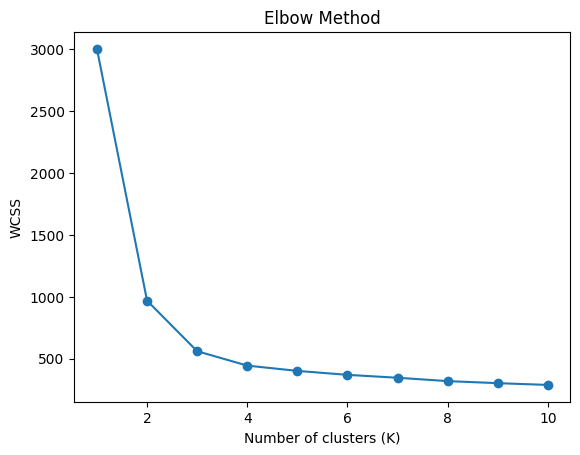

In [4]:
#Choosing K — Elbow Method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
wcss=[]

for k in range(1,11):
  kmeans=KMeans(n_clusters=k,random_state=42,n_init=10)
  kmeans.fit(X_scaled)
  wcss.append(kmeans.inertia_)

plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

The elbow point appears at K = 3, where the decrease in WCSS starts to slow down significantly. Before K = 3, there is a sharp reduction in WCSS, indicating better cluster formation. After this point, the improvement becomes marginal.

Therefore, K = 3 is selected as the optimal number of clusters, as it provides a good balance between model complexity and performance.

In [8]:
#K-Means Clustering
k=3
kmeans=KMeans(n_clusters=k,random_state=42,n_init=10)
df["cluster"]=kmeans.fit_predict(X_scaled)
centroids=pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]
)
centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


1. Cluster 0 represents young customers with low spending and frequent visits. They purchase fewer categories and have smaller basket sizes, indicating budget-conscious but active shoppers.
2. Cluster 1 represents older, high-value customers with very high spending but infrequent visits. They have large basket sizes and purchase many categories, indicating premium or bulk buyers.
3. Cluster 2 represents middle-aged customers with moderate spending and visit frequency. They show balanced behavior in terms of basket size and category purchases, representing average or regular customers.

In [10]:
# Dimensionality Reduction with PCA
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X_scaled)
print("Explained Variance Ratio:",pca.explained_variance_ratio_)
loadings=pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],
    index=["PC1","PC2"]
)
loadings

Explained Variance Ratio: [0.83560354 0.05568764]


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


1. The first principal component (PC1) explains a large portion of the variance (~83.6%) and is influenced by features such as annual_spend, basket_size, age, and number of categories purchased. This indicates that PC1 mainly captures overall customer value and spending behavior.

2. The second principal component (PC2) explains a smaller portion of variance (~5.6%) and is strongly influenced by days_since_last_visit. This suggests that PC2 primarily represents customer recency or inactivity.

Together, these components help reduce the dataset to two dimensions while retaining most of the important information.

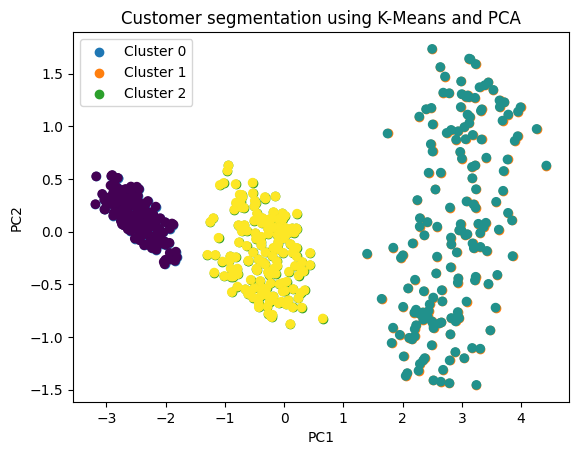

In [13]:
# Cluster Visualisation
for i in range(k):
  plt.scatter(
      X_pca[df["cluster"]==i,0],
      X_pca[df["cluster"]==i,1],
      label=f"Cluster {i}"
      )
plt.scatter(X_pca[:,0],X_pca[:,1],c=df["cluster"])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer segmentation using K-Means and PCA")
plt.legend()
plt.show()
